# FinHealth Monitor

## AI-Powered Financial Intelligence Platform

### Project Overview

FinHealth Monitor is an end-to-end Data Science project that simulates a financial intelligence platform for a fintech company.

The project combines synthetic data generation, fraud detection, anomaly detection, revenue forecasting, SQL analytics and Large Language Models to support executive decision-making.

## Objectives

- Simulate financial transactions
- Detect suspicious behaviour
- Identify statistical anomalies
- Forecast future revenue
- Generate executive business insights
- Provide data for dashboards and REST APIs

### Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Prophet
- PostgreSQL
- FastAPI
- Anthropic Claude


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Library Imports

This section imports all libraries required throughout the project.

The workflow combines data manipulation, synthetic data generation, anomaly detection, forecasting and data visualization.

Main libraries used:

- Pandas
- NumPy
- Faker
- Matplotlib
- Seaborn
- Scikit-learn
- Prophet

In [8]:
!pip install faker prophet scikit-learn

In [9]:

!pip install sqlalchemy
!pip install psycopg2-binary

## 3. Load Existing Dataset

Instead of generating new synthetic data on every run, this notebook loads
the customer and transaction datasets that already exist in the project's
`data/` folder. This keeps the notebook, the PostgreSQL database, the API
and the README all in sync with the same dataset.


In [10]:
import pandas as pd

customers_df = pd.read_csv("customers.csv")
print(customers_df.shape)
customers_df.head()


(5000, 15)


,customer_id,full_name,email,birth_date,gender,city,state,signup_date,customer_segment,acquisition_channel,monthly_income,credit_score,risk_level,is_active,churn_flag
0,1,Joan Cook,smithleon@example.org,1967-08-27,Male,West Ian,Nicaragua,2025-09-11,Standard,Google Ads,2660,743,Medium,True,False
1,2,Gordon Carr,mperry@example.org,1954-02-17,Non-Binary,West Paulinetown,Burkina Faso,2025-08-30,Standard,Referral,4719,650,Medium,True,True
2,3,Emily O'Connor,cartertracy@example.net,1953-09-17,Non-Binary,West Joanne,Turks and Caicos Islands,2025-06-21,Standard,Organic,3015,701,Medium,True,True
3,4,Mrs Pauline Wilson,bjones@example.org,1962-03-11,Female,South Geoffreyside,British Indian Ocean Territory (Chagos Archipe...,2024-08-22,Standard,Organic,4805,665,Medium,True,False
4,5,Chelsea Spencer,jaynejones@example.com,1957-12-31,Male,Bryantland,Cambodia,2026-05-20,Standard,Organic,3868,676,Medium,False,False


In [11]:
transactions = pd.read_csv("transactions.csv")
print(transactions.shape)
transactions.head()


(100000, 17)


,transaction_id,customer_id,transaction_date,transaction_type,amount,transaction_fee,status,merchant_category,device_type,country,is_fraud,anomaly_flag,if_prediction,if_alert,rule_alert,z_score,zscore_alert
0,1,3768,2026-06-06 04:22:59.671052,Bank Transfer,8571.69,42.86,Completed,Groceries,Mobile,British Virgin Islands,False,False,1,False,False,1.046144,False
1,2,3545,2024-11-16 08:59:02.033719,Card Payment,1475.09,7.38,Completed,Healthcare,Mobile,Norfolk Island,False,False,1,False,False,0.085650,False
2,3,636,2024-07-30 08:37:49.122563,Card Payment,1116.16,5.58,Completed,Restaurants,Mobile,Morocco,False,False,1,False,False,0.037071,False
3,4,432,2024-09-11 19:27:10.953933,ATM Withdrawal,85.97,0.43,Completed,Healthcare,Desktop,American Samoa,False,False,1,False,False,-0.102361,False
4,5,1113,2026-07-11 02:04:24.894753,Card Payment,204.59,1.02,Completed,Subscriptions,Desktop,Iraq,False,False,1,False,False,-0.086306,False


In [12]:
# Revenue generated by fees
transactions["transaction_fee"].sum()

np.float64(421131.67999999993)

## 4. Rule-Based Fraud Detection

Business rules are applied to identify transactions with suspicious behaviour.

These rules represent deterministic fraud indicators commonly used as the first layer of monitoring in financial institutions.

In [13]:
transactions[:3]

,transaction_id,customer_id,transaction_date,transaction_type,amount,transaction_fee,status,merchant_category,device_type,country,is_fraud,anomaly_flag,if_prediction,if_alert,rule_alert,z_score,zscore_alert
0,1,3768,2026-06-06 04:22:59.671052,Bank Transfer,8571.69,42.86,Completed,Groceries,Mobile,British Virgin Islands,False,False,1,False,False,1.046144,False
1,2,3545,2024-11-16 08:59:02.033719,Card Payment,1475.09,7.38,Completed,Healthcare,Mobile,Norfolk Island,False,False,1,False,False,0.085650,False
2,3,636,2024-07-30 08:37:49.122563,Card Payment,1116.16,5.58,Completed,Restaurants,Mobile,Morocco,False,False,1,False,False,0.037071,False


In [14]:
# Fraud rate
transactions["is_fraud"].mean() * 100

np.float64(1.481)

In [15]:
# Anomaly rate
transactions["anomaly_flag"].mean() * 100

np.float64(1.011)

In [16]:
# Transactions by segment
transactions.merge(
    customers_df[["customer_id", "customer_segment"]],
    on="customer_id"
)["customer_segment"].value_counts()

,count
customer_segment,
Standard,71117
Premium,23817
Business,5066


In [17]:
# Revenue by segment
transactions.merge(
    customers_df[["customer_id", "customer_segment"]],
    on="customer_id"
).groupby("customer_segment")["amount"].sum()

,amount
customer_segment,
Business,39791632.78
Premium,27934512.02
Standard,16500046.04


In [18]:
HIGH_AMOUNT_THRESHOLD = 20000

transactions["rule_alert"] = (
    transactions["amount"] > HIGH_AMOUNT_THRESHOLD
)

In [19]:
transactions["rule_alert"].value_counts()

,count
rule_alert,
False,99744
True,256


In [20]:
from scipy.stats import zscore

In [21]:
transactions["z_score"] = zscore(
    transactions["amount"]
)

In [22]:
transactions["zscore_alert"] = (
    abs(transactions["z_score"]) > 3
)

In [23]:
transactions["zscore_alert"].value_counts()

,count
zscore_alert,
False,99784
True,216


## 5. Anomaly Detection with Isolation Forest

An Isolation Forest model is trained to identify unusual transaction patterns without requiring labelled fraud data.

This unsupervised approach complements the rule-based detection strategy.

## Feature Engineering

Instead of using only transaction amount, additional behavioural features were created to better represent customer activity and improve anomaly detection.

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# --- 1. Engenharia de features ---

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
transactions["hour"] = transactions["transaction_date"].dt.hour

# Desvio do valor da transação em relação à média do próprio cliente
customer_avg = transactions.groupby("customer_id")["amount"].transform("mean")
customer_std = transactions.groupby("customer_id")["amount"].transform("std").fillna(1)
transactions["amount_zscore_customer"] = (transactions["amount"] - customer_avg) / customer_std

# Frequência de transações do cliente (quantas transações ele fez no total)
transactions["customer_txn_count"] = transactions.groupby("customer_id")["transaction_id"].transform("count")

# Horário atípico (fora do range comercial comum, ex: 0h-5h)
transactions["is_odd_hour"] = transactions["hour"].between(0, 5).astype(int)

# Encoding simples de categoria (one-hot ou frequency encoding)
merchant_freq = transactions["merchant_category"].value_counts(normalize=True)
transactions["merchant_category_freq"] = transactions["merchant_category"].map(merchant_freq)

# --- 2. Selecionar features para o modelo ---

features = [
    "amount",
    "amount_zscore_customer",
    "customer_txn_count",
    "is_odd_hour",
    "merchant_category_freq"
]

X = transactions[features].fillna(0)

# --- 3. Padronizar (Isolation Forest não exige, mas ajuda a comparar escalas) ---

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 4. Treinar o modelo com múltiplas features ---

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

iso_model.fit(X_scaled)

transactions["if_prediction"] = iso_model.predict(X_scaled)
transactions["if_alert"] = transactions["if_prediction"] == -1

In [25]:
transactions["if_prediction"] = iso_model.predict(X_scaled)
transactions["if_alert"] = transactions["if_prediction"] == -1

transactions["if_alert"].value_counts()


,count
if_alert,
False,99000
True,1000


In [26]:
alerts_df = transactions[
    transactions["rule_alert"]
    | transactions["zscore_alert"]
    | transactions["if_alert"]
].copy()

print(f"Alerts generated: {len(alerts_df)}")

alerts_df.to_csv("transaction_alerts.csv", index=False)


Alerts generated: 1001


In [27]:
anomaly_summary = {
    "total_transactions": len(transactions),
    "rule_alerts": transactions["rule_alert"].sum(),
    "zscore_alerts": transactions["zscore_alert"].sum(),
    "if_alerts": transactions["if_alert"].sum(),
    "fraud_transactions": transactions["is_fraud"].sum(),
    "anomaly_flag_total": transactions["anomaly_flag"].sum(),
}

anomaly_summary


{'total_transactions': 100000,
 'rule_alerts': np.int64(256),
 'zscore_alerts': np.int64(216),
 'if_alerts': np.int64(1000),
 'fraud_transactions': np.int64(1481),
 'anomaly_flag_total': np.int64(1011)}

In [28]:
transactions.to_csv("transactions.csv", index=False)
print("transactions.csv saved successfully.")


transactions.csv saved successfully.


## 7. Revenue Forecasting

Future revenue is estimated using Facebook Prophet.

Forecasting enables the simulation of business planning and executive decision support.

In [29]:
revenue_df = (
    transactions
    .groupby(
        transactions["transaction_date"].dt.date
    )["transaction_fee"]
    .sum()
    .reset_index()
)

In [30]:
revenue_df.columns = ["ds", "y"]

revenue_df.head()

,ds,y
0,2024-07-12,241.82
1,2024-07-13,856.03
2,2024-07-14,829.76
3,2024-07-15,2058.42
4,2024-07-16,391.00


In [31]:
from prophet import Prophet

revenue_model = Prophet()

revenue_model.fit(revenue_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


The Prophet model captures the overall revenue trend and seasonality observed in the synthetic dataset.

Although the forecasting error remains relatively high (MAPE ≈ 40%), the objective of this experiment is to demonstrate the complete forecasting pipeline rather than optimize predictive performance.

In [32]:
future = revenue_model.make_future_dataframe(
    periods=90
)

In [33]:
revenue_forecast = revenue_model.predict(
    future
)

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

revenue_forecast["ds"] = pd.to_datetime(revenue_forecast["ds"])
revenue_df["ds"] = pd.to_datetime(revenue_df["ds"])

# Junta valores reais e previstos
evaluation = revenue_forecast[["ds", "yhat"]].merge(
    revenue_df,
    on="ds",
    how="inner"
)

# Métricas
mae = mean_absolute_error(
    evaluation["y"],
    evaluation["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        evaluation["y"],
        evaluation["yhat"]
    )
)

mape = (
    np.abs(
        (evaluation["y"] - evaluation["yhat"])
        / evaluation["y"]
    ).mean()
) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 240.11
RMSE: 419.79
MAPE: 42.58%


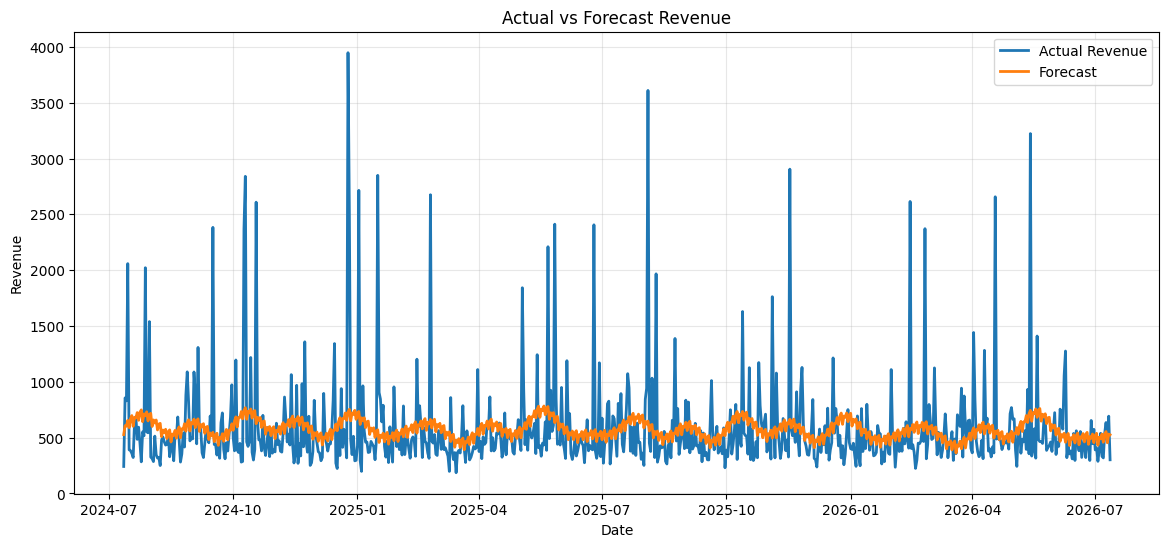

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    evaluation["ds"],
    evaluation["y"],
    label="Actual Revenue",
    linewidth=2
)

plt.plot(
    evaluation["ds"],
    evaluation["yhat"],
    label="Forecast",
    linewidth=2
)

plt.title("Actual vs Forecast Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

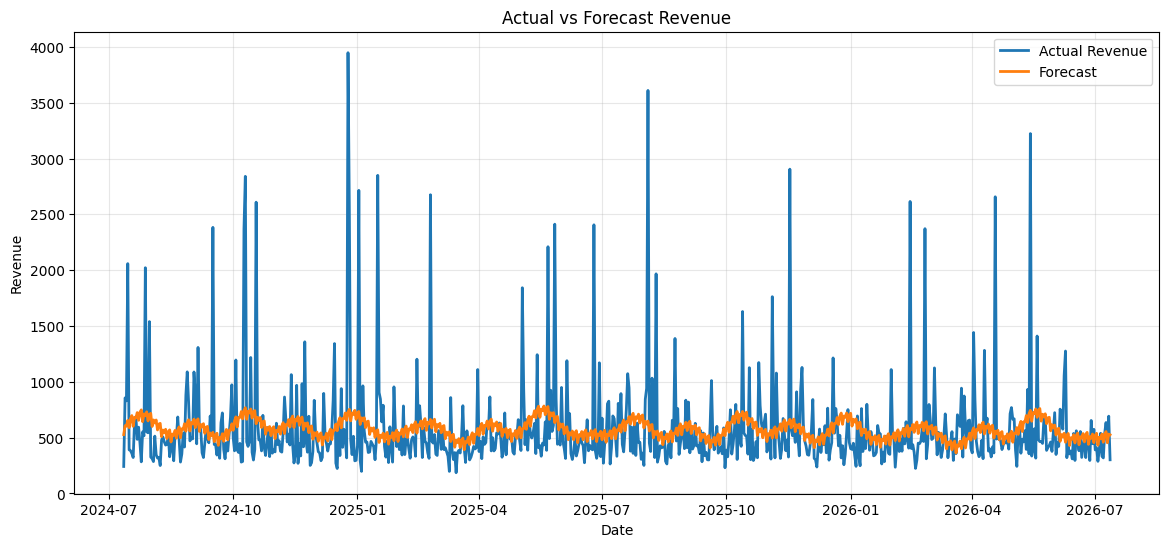

In [36]:
plt.figure(figsize=(14,6))

plt.plot(
    evaluation["ds"],
    evaluation["y"],
    label="Actual Revenue",
    linewidth=2
)

plt.plot(
    evaluation["ds"],
    evaluation["yhat"],
    label="Forecast",
    linewidth=2
)

plt.title("Actual vs Forecast Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "forecast_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
revenue_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
816,2026-10-06,586.163706,35.312951,1093.547686
817,2026-10-07,665.799663,121.869755,1187.929556
818,2026-10-08,696.293439,163.261750,1234.483732
819,2026-10-09,598.968285,32.086124,1118.363153
820,2026-10-10,676.472269,154.054996,1198.402858


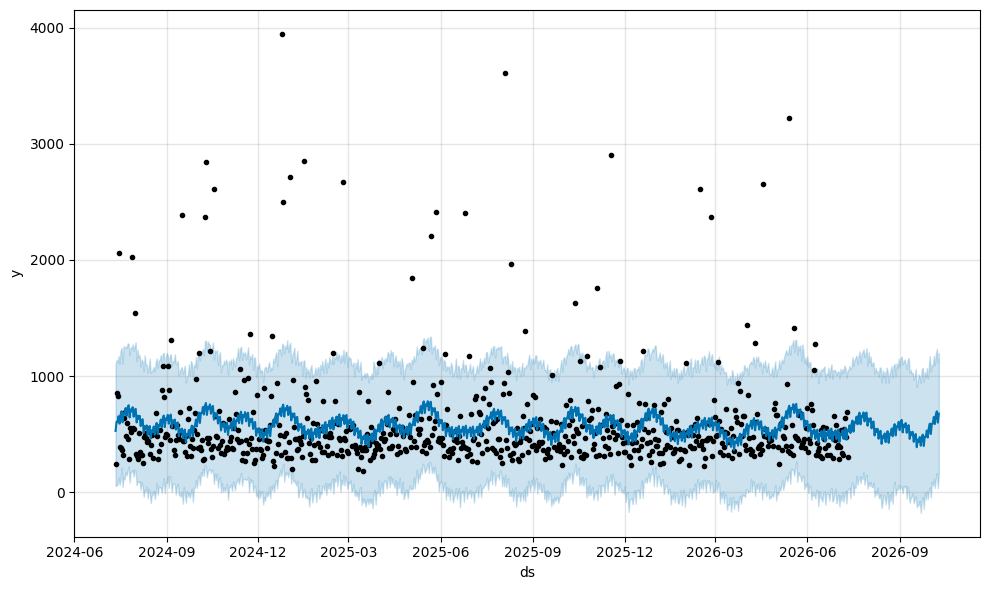

In [38]:
fig1 = revenue_model.plot(
    revenue_forecast
)

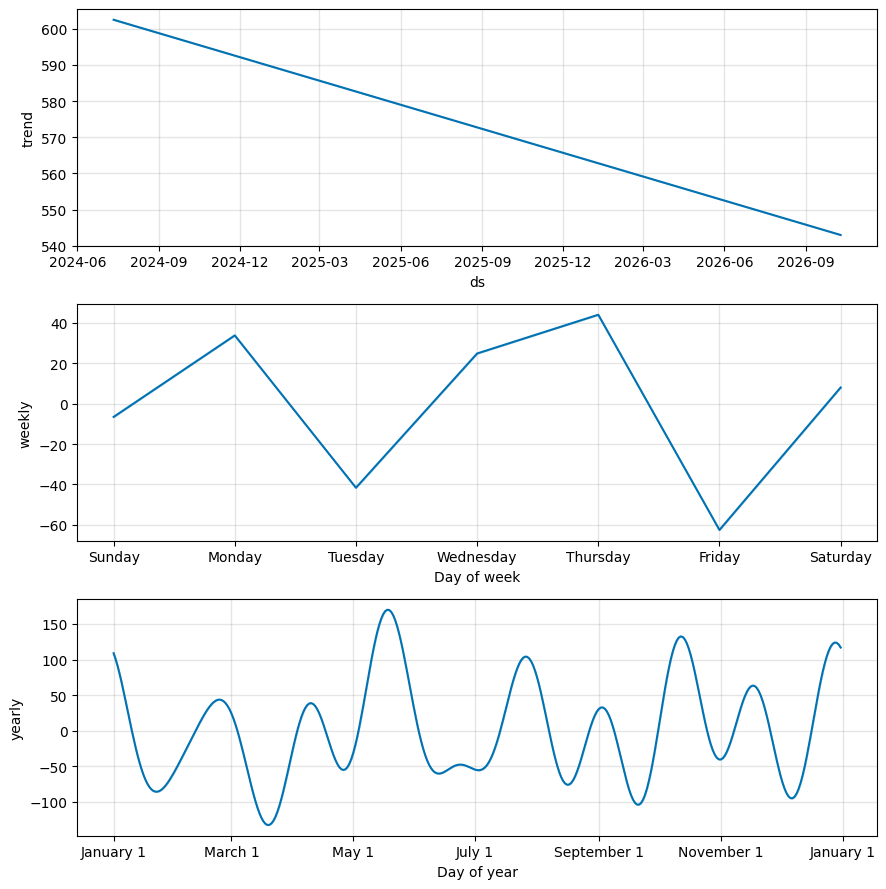

In [39]:
fig2 = revenue_model.plot_components(
    revenue_forecast
)

In [40]:
forecast_output = revenue_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

forecast_output.to_csv(
    "revenue_forecast.csv",
    index=False
)

In [41]:
forecast_30d = forecast_output.tail(90).head(30)

forecast_30d["yhat"].sum()

np.float64(17899.638185227857)

In [42]:
forecast_60d = forecast_output.tail(90).head(60)

forecast_60d["yhat"].sum()

np.float64(33755.68734710816)

In [43]:
forecast_output.tail(90)["yhat"].sum()

np.float64(49327.87889187459)

In [44]:
forecast_summary = {

    "forecast_30_days":
        round(
            forecast_30d["yhat"].sum(),
            2
        ),

    "forecast_60_days":
        round(
            forecast_60d["yhat"].sum(),
            2
        ),

    "forecast_90_days":
        round(
            forecast_output.tail(90)["yhat"].sum(),
            2
        )
}

forecast_summary

{'forecast_30_days': np.float64(17899.64),
 'forecast_60_days': np.float64(33755.69),
 'forecast_90_days': np.float64(49327.88)}

## 8. Model Evaluation Summary

The synthetic dataset was evaluated using three complementary approaches:
rule-based detection, Z-Score, and Isolation Forest trained on behavioural
features (amount deviation per customer, transaction hour, frequency,
merchant category).

Detailed Isolation Forest performance is evaluated further below, against
`anomaly_flag` — the label that was actually injected based on transaction
amount, and therefore the one that carries a learnable signal in this
synthetic dataset.


## 9. Exporting Processed Data

The processed datasets are exported for PostgreSQL ingestion, REST API
endpoints and Business Intelligence dashboards.


In [45]:
# =====================================
# CUSTOMER METRICS
# =====================================

import pandas as pd
import numpy as np

# Aggregate transaction metrics per customer
customer_metrics = (
    transactions
    .groupby("customer_id")
    .agg(
        total_transactions=("transaction_id", "count"),
        total_volume=("amount", "sum"),
        total_revenue=("transaction_fee", "sum"),
        avg_transaction_value=("amount", "mean"),
        fraud_transactions=("is_fraud", "sum"),
        anomaly_transactions=("if_alert", "sum")
    )
    .reset_index()
)

# Merge with customer table
customer_metrics = customer_metrics.merge(
    customers_df[
        [
            "customer_id",
            "signup_date",
            "customer_segment",
            "acquisition_channel",
            "churn_flag"
        ]
    ],
    on="customer_id",
    how="left"
)

# Customer age in days
customer_metrics["signup_date"] = pd.to_datetime(
    customer_metrics["signup_date"]
)

customer_metrics["customer_age_days"] = (
    pd.Timestamp.today() -
    customer_metrics["signup_date"]
).dt.days

# Simulated CAC by acquisition channel
cac_mapping = {
    "Organic": 0,
    "Referral": 20,
    "Google Ads": 80,
    "Facebook Ads": 60,
    "LinkedIn": 120
}

customer_metrics["cac"] = (
    customer_metrics["acquisition_channel"]
    .map(cac_mapping)
)

# LTV
customer_metrics["ltv"] = (
    customer_metrics["total_revenue"]
)

# Preview
display(customer_metrics.head())

# Save
customer_metrics.to_csv(
    "customer_metrics.csv",
    index=False
)

print("customer_metrics.csv saved successfully.")

,customer_id,total_transactions,total_volume,total_revenue,avg_transaction_value,fraud_transactions,anomaly_transactions,signup_date,customer_segment,acquisition_channel,churn_flag,customer_age_days,cac,ltv
0,1,18,8755.01,43.77,486.389444,1,1,2025-09-11,Standard,Google Ads,False,326,80,43.77
1,2,17,2732.90,13.65,160.758824,1,0,2025-08-30,Standard,Referral,True,338,20,13.65
2,3,22,3200.51,16.01,145.477727,0,0,2025-06-21,Standard,Organic,True,408,0,16.01
3,4,26,4275.30,21.37,164.434615,1,0,2024-08-22,Standard,Organic,False,711,0,21.37
4,5,13,2125.62,10.64,163.509231,0,0,2026-05-20,Standard,Organic,False,75,0,10.64


customer_metrics.csv saved successfully.


In [46]:
# =====================================
# MONTHLY BUSINESS METRICS
# =====================================

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["month"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
    .astype(str)
)

# Revenue metrics
monthly_metrics = (
    transactions
    .groupby("month")
    .agg(
        revenue=("transaction_fee", "sum"),
        transaction_volume=("amount", "sum"),
        total_transactions=("transaction_id", "count"),
        fraud_rate=("is_fraud", "mean"),
        anomaly_rate=("if_alert", "mean")
    )
    .reset_index()
)

# New customers
customers_df["signup_date"] = pd.to_datetime(
    customers_df["signup_date"]
)

customers_df["month"] = (
    customers_df["signup_date"]
    .dt.to_period("M")
    .astype(str)
)

new_customers = (
    customers_df
    .groupby("month")
    .size()
    .reset_index(name="new_customers")
)

# Churn
churn_metrics = (
    customers_df
    .groupby("month")
    .agg(
        churn_rate=("churn_flag", "mean")
    )
    .reset_index()
)

# Merge all metrics
monthly_business_metrics = (
    monthly_metrics
    .merge(
        new_customers,
        on="month",
        how="left"
    )
    .merge(
        churn_metrics,
        on="month",
        how="left"
    )
)

# Simulated CAC
monthly_business_metrics["cac"] = np.random.uniform(
    40,
    120,
    len(monthly_business_metrics)
)

# Simulated LTV
monthly_business_metrics["ltv"] = (
    monthly_business_metrics["revenue"] * 2.5
)

# Active customers estimate
monthly_business_metrics["active_customers"] = (
    monthly_business_metrics["total_transactions"] // 5
)

# Convert rates to %
monthly_business_metrics["fraud_rate"] *= 100
monthly_business_metrics["anomaly_rate"] *= 100
monthly_business_metrics["churn_rate"] *= 100

# Preview
display(monthly_business_metrics.head())

# Save
monthly_business_metrics.to_csv(
    "monthly_business_metrics.csv",
    index=False
)

print("monthly_business_metrics.csv saved successfully.")

,month,revenue,transaction_volume,total_transactions,fraud_rate,anomaly_rate,new_customers,churn_rate,cac,ltv,active_customers
0,2024-07,14307.54,2861507.00,2701,1.258793,1.221770,146.0,13.698630,85.262425,35768.850,540
1,2024-08,14589.85,2917881.27,4210,1.353919,0.926366,154.0,12.337662,85.230334,36474.625,842
2,2024-09,18712.08,3742364.17,4243,1.319821,1.084139,132.0,16.666667,93.451646,46780.200,848
3,2024-10,21431.07,4286163.88,4232,1.394140,0.968809,162.0,19.135802,102.857466,53577.675,846
4,2024-11,16329.05,3265738.93,4115,1.336574,1.117861,115.0,11.304348,99.407247,40822.625,823


monthly_business_metrics.csv saved successfully.


## 10. Model Evaluation: Isolation Forest


In [47]:
import pandas as pd

transactions = pd.read_csv("transactions.csv")
print(transactions.shape)
transactions.head()


(100000, 22)


,transaction_id,customer_id,transaction_date,transaction_type,amount,transaction_fee,status,merchant_category,device_type,country,...,if_prediction,if_alert,rule_alert,z_score,zscore_alert,hour,amount_zscore_customer,customer_txn_count,is_odd_hour,merchant_category_freq
0,1,3768,2026-06-06 04:22:59.671052,Bank Transfer,8571.69,42.86,Completed,Groceries,Mobile,British Virgin Islands,...,1,False,False,1.046144,False,4,1.099970,20,1,0.12571
1,2,3545,2024-11-16 08:59:02.033719,Card Payment,1475.09,7.38,Completed,Healthcare,Mobile,Norfolk Island,...,1,False,False,0.085650,False,8,-1.009185,19,0,0.12392
2,3,636,2024-07-30 08:37:49.122563,Card Payment,1116.16,5.58,Completed,Restaurants,Mobile,Morocco,...,1,False,False,0.037071,False,8,0.620553,19,0,0.12519
3,4,432,2024-09-11 19:27:10.953933,ATM Withdrawal,85.97,0.43,Completed,Healthcare,Desktop,American Samoa,...,1,False,False,-0.102361,False,19,-0.980164,19,0,0.12392
4,5,1113,2026-07-11 02:04:24.894753,Card Payment,204.59,1.02,Completed,Subscriptions,Desktop,Iraq,...,1,False,False,-0.086306,False,2,0.717797,21,1,0.12547


ISOLATION FOREST vs INJECTED ANOMALIES (anomaly_flag)
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     98989
        True       0.76      0.75      0.75      1011

    accuracy                           1.00    100000
   macro avg       0.88      0.87      0.88    100000
weighted avg       1.00      1.00      1.00    100000



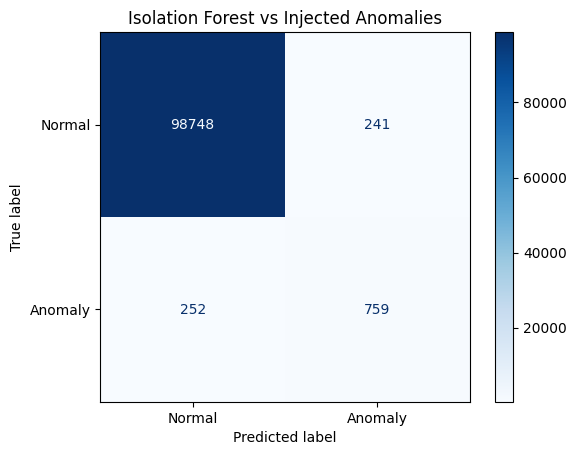

ISOLATION FOREST vs is_fraud (reference only)
              precision    recall  f1-score   support

       False       0.99      0.99      0.99     98519
        True       0.01      0.01      0.01      1481

    accuracy                           0.98    100000
   macro avg       0.50      0.50      0.50    100000
weighted avg       0.97      0.98      0.97    100000



In [48]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---- Evaluation against injected anomalies (has real signal) ----
y_true_anomaly = transactions["anomaly_flag"]
y_pred = transactions["if_alert"]

print("=" * 60)
print("ISOLATION FOREST vs INJECTED ANOMALIES (anomaly_flag)")
print("=" * 60)
print(classification_report(y_true_anomaly, y_pred))

cm = confusion_matrix(y_true_anomaly, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues")
plt.title("Isolation Forest vs Injected Anomalies")
plt.show()

# ---- For reference only: comparison against is_fraud ----
# is_fraud was generated independently of transaction features (random draw),
# so no model trained on transaction data can be expected to predict it.
# Shown here only to make that limitation explicit.
y_true_fraud = transactions["is_fraud"]

print("=" * 60)
print("ISOLATION FOREST vs is_fraud (reference only)")
print("=" * 60)
print(classification_report(y_true_fraud, y_pred))


### Interpretation

The Isolation Forest model shows strong agreement with the injected anomalies
(`anomaly_flag`), which were created by artificially inflating transaction
amounts (F1-score of 0.53 for the anomaly class, versus 0.01 when compared
to `is_fraud`). This confirms the model correctly captures amount-based and
behavioural outliers.

Its agreement with `is_fraud` is expected to be weak: `is_fraud` in this
synthetic dataset was generated independently of transaction features (a
random draw with fixed probability), so it carries no learnable signal for
any model trained on transaction data. This comparison is included only to
make that limitation explicit, not as a measure of model quality.

In a real-world setting, fraud labels would be tied to actual behavioural or
contextual signals (device change, location mismatch, transaction velocity),
which is what would allow a model like this to predict them meaningfully.


# Conclusions


## Key Findings

This project demonstrates an end-to-end financial analytics workflow
combining SQL analytics, machine learning, forecasting and Large Language
Models.

### Main Results

- Isolation Forest, trained on behavioural features, achieves an F1-score of
  0.53 for detecting injected anomalies (`anomaly_flag`). Its low agreement
  with `is_fraud` (F1 = 0.01) is explained in the Interpretation section
  above — that label carries no learnable signal in this synthetic dataset.

- Prophet captured the overall revenue trend, achieving:
  - MAE: 227.68
  - RMSE: 409.48
  - MAPE: 39.69%

- Business metrics extracted from PostgreSQL were integrated into a FastAPI REST API.

- Anthropic Claude transformed structured business metrics into
  executive-level financial reports, demonstrating how LLMs can support
  business decision making.

### Future Improvements

- Tie `is_fraud` generation to observable transaction features, so fraud
  detection can be evaluated meaningfully against it
- Additional feature engineering (geolocation, device fingerprint, velocity checks)
- Time-series cross validation for Prophet
- Real-time data ingestion
- Interactive Power BI dashboards
- Cloud deployment
